# 面向能量套利与削峰的电池储能调度优化

## 执行摘要

某并网商业站点在计量电力负荷之外运行着一套 2 MW / 8 MWh 的锂离子电池。该站点按两种方式计费：按小时的日前**电能价格**（$/MWh）和按月对其单个最高电网进口区间收取的**需量电费**（$/MW）。资产管理者必须逐小时决定何时给电池充电（买入廉价电能、抬高电网取电）以及何时放电（抵消昂贵电能、降低电网取电）。两条价值流相互竞争：**能量套利**（夜间低价买入、傍晚高峰放电）与**削峰**（压低计费的电网最大值）。充电并非免费——往返效率意味着约 10% 的存储电能会损失——因此该调度是一次真正的优化，而非启发式经验法。

本 notebook 端到端地构建这一决策。它首先合成一条真实的 24 小时日前价格曲线（含早晚双峰以及夜间谷底）和一条相关联的站点负荷曲线，然后用 **PROC MEANS** 及稳健的 **PROC UNIVARIATE** 2.5/97.5 分位价格带对二者进行画像。核心是 **PROC OPTMODEL** 中的一个线性规划：以逐小时充电、放电和荷电状态为决策变量，再加上一个计费峰值变量，约束条件包括累积荷电状态平衡（含独立的充/放电效率）、功率与容量限制以及峰值定义约束。目标函数最大化扣除需量电费后的套利利润。**PROC SQL** 随后量化基线与优化后的成本对比，三幅 **PROC SGPLOT** 面板分别可视化充放电调度与价格的对照、荷电状态轨迹以及被削平的电网进口曲线。

**在合成日上的结果：**优化器在最便宜的夜间小时给电池充满电，向早晚两个价格峰放电，在午间价格谷时段重新充电，并且——关键在于——克制其充电功率，使其绝不制造新的电网峰值。每日电能成本从 **\$2,903.78 降至 \$2,528.43**——即 **\$375.34（12.9%）的套利节省**——同时计费的电网最大值从 **3.59 MW 降至 3.43 MW**（约 **0.16 MW**），在假定的按日摊分需量电费下再值 **\$18.98**。同一模型只需扩展索引集与约束，即可推广到更长的时域、多个价格情景或考虑退化的循环。

## 数据来源

所有数据均为**合成数据**，在第一个代码单元中通过 `CALL STREAMINIT(20260605)` 内联生成以保证可复现。无外部文件或网络访问。仅一个数据集 `price_load`，含 24 行小时数据，代表单个运行日。

| 变量 | 类型 | 单位 | 说明 |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | 运行日的小时（时域索引） |
| `price` | num | $/MWh | 日前电能价格：夜间谷底、早晚双峰，含高斯噪声（下限 $5） |
| `load` | num | MW | 站点电力需量，与日内活动相关（下限 0.3 MW） |
| `day_type` | char | — | 电价时段标志：`峰时`（17–21 时）对 `平时`，用于峰/谷价差汇总 |

电池参数是 PROC OPTMODEL 内部固定的模型常量：8 MWh 可用容量、2 MW 最大充/放电功率、0.95 充电与 0.95 放电效率（约 90% 往返）、初始荷电状态 0 MWh，以及对当日计费电网峰值施加的 \$120/MW 需量电费（按月需量电费的按日摊分份额）。

# 电池储能调度优化
## 面向并网站点的能量套利与削峰

某商业站点在其电表后运行一套 **2 MW / 8 MWh 电池**。其电费账单有两部分：按小时的**电能价格**（$/MWh）和按月对单个最高电网进口区间收取的**需量电费**（$/MW）。运营者希望得到一份逐小时的充/放电调度，同时捕获两条价值流：

- **套利**——存储廉价的夜间电能，在昂贵的高峰小时释放。
- **削峰**——在需量尖峰期间放电，以降低计费的电网最大值。

由于往返效率会损失约 10% 的存储电能，这一权衡并不简单，值得进行一次真正的优化。我们在 **PROC OPTMODEL** 中将其表述为线性规划，然后量化并可视化结果。

> 以下所有数据均为合成并内联生成——本 notebook 完全自包含，数秒内即可运行完毕。

## 1. 生成合成的日前价格与负荷曲线

我们构建一个运行日（24 行小时数据）。价格曲线有一个夜间谷底以及早晚双峰；站点负荷与日内活动相关。固定的种子保证运行可复现。我们还标记法定的分时用电峰值窗口，以便稍后汇总峰/谷价差。

In [1]:
数据 price_load;
    调用 streaminit(20260605);
    长度 day_type $12;
    循环 hour = 0 到 23;
        /* 日内电价（$/兆瓦时）：早高峰 + 晚高峰 */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        如果 price < 5 那么 price = 5;

        /* 站点负荷（兆瓦）：夜间低谷、傍晚爬坡 */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        如果 LOAD < 0.3 那么 LOAD = 0.3;

        如果 hour >= 17 并且 hour <= 21 那么 day_type = '峰时';
        否则 day_type = '平时';
        输出;
    结束;
    删除 BASE;
运行;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. 对价格与负荷分布进行画像

在优化之前，我们对输入做合理性检查。最便宜与最昂贵小时之间的价差正是套利所变现的对象，而最大负荷则锚定了削峰机会。

In [2]:
过程 均值 数据=price_load n mean std MIN MAX maxdec=2;
    变量 price LOAD;
    标签 price='电价（$/兆瓦时）' LOAD='站点负荷（兆瓦）';
    标题 '电价与站点负荷的日内统计';
运行;

                                                      电价与站点负荷的日内统计                                                      

                                                  The MEANS Procedure

 Variable  Label                           N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------------------
 price     电价（$/兆瓦时）                      24       46.29       15.81       18.57       79.27
 LOAD      站点负荷（兆瓦）                       24        2.47        0.48        1.71        3.59
 -------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. 峰段与谷段价差

按分时用电标志分组，可以看出高峰小时相较谷段基线富含多少价值——这正是电池所利用的结构性信号。

In [3]:
过程 均值 数据=price_load mean MIN MAX maxdec=2;
    分类 day_type;
    变量 price;
    标签 day_type='时段类型' price='电价（$/兆瓦时）';
    标题 '按时段类型划分的电价';
运行;

                                                       按时段类型划分的电价                                                       

                                                  The MEANS Procedure

                                   Analysis Variable : price 电价（$/兆瓦时）

                                                  N
                                时段类型            Obs       Mean      Minimum      Maximum
                                --------------------------------------------------------
                                峰时                5      68.45        54.88        79.27
                                平时               19      40.46        18.57        54.89
                                --------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. 稳健价格带（2.5 / 97.5 分位）

我们用 2.5 / 97.5 分位带来刻画价格尾部。带 `PCTLPTS=` 的 **PROC UNIVARIATE** 可干净地计算任意分位数，这正是计算分数分位数的正确工具。

In [4]:
过程 UNIVARIATE 数据=price_load NOPRINT;
    变量 price;
    输出 out=price_band pctlpts=2.5 97.5 pctlpre=p_;
运行;

过程 打印 数据=price_band noobs;
    标题 '电价的第 2.5 与 97.5 百分位（$/兆瓦时）';
运行;

                                               电价的第 2.5 与 97.5 百分位（$/兆瓦时）                                               

P_2_5  P_97_5
18.57   79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. 调度优化（线性规划）

我们将逐小时的价格与负荷读入 PROC OPTMODEL 并声明：

- `chg[h]`、`dis[h]`——逐小时充/放电功率（MW），受 2 MW 逆变器额定值约束。
- `soc[h]`——荷电状态（MWh），受 8 MWh 可用容量约束。
- `peak`——计费的电网最大值（MW）。

**约束。** `soc_balance` 以独立的充/放电效率逐小时累积净能量（小时递推的累加求和形式）。`peak_def` 强制 `peak` 支配每一小时的净电网进口，因此最小化它即可削减需量电费。

**目标。** 最大化套利利润——将整日 `price × (discharge − charge)` 求和——再减去对计费峰值收取的需量电费。我们作为连续 LP 求解。

In [5]:
过程 optmodel;
    设置 HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ 数据 price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* 电池：8 兆瓦时可用容量、2 兆瓦功率、约 90% 往返效率 */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* 需量电费按当日计费的电网峰值计取（$/兆瓦）。
       商业需量电费按月计取；120 是当月度电费摊销到当日后，
       削减今日电网最大值的边际价值。它足够大，使优化器
       宁可压低充电功率，也不去制造一个新的、更高的峰值。 */
    num demand_chg = 120;

    /* 决策变量（充电/放电为兆瓦，荷电量为兆瓦时） */
    变量 chg{HOURS}  >= 0 <= p_max;
    变量 dis{HOURS}  >= 0 <= p_max;
    变量 soc{HOURS}  >= 0 <= capacity;
    变量 peak        >= 0;   /* 用于需量电费的计费电网峰值（兆瓦） */

    /* 电池动作后的净电网购电（兆瓦） */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* 累积荷电量：截至第 h 小时的进能量减出能量，
       并计入充放电效率。等价于逐小时递推，
       但在此表述为对此前各小时的累加和。 */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* 削峰：计费峰值为当日电网购电的最大值 */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* 最大化能量套利净收益（扣除峰值需量电费后） */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE 数据 dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;

                                               电价的第 2.5 与 97.5 百分位（$/兆瓦时）                                               


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. 最优的逐小时调度

求解后的表格显示：充电分散在廉价的夜间与午间小时——被调节至约 1.0–1.7 MW，使其绝不设立新的电网峰值——放电集中在早晚价格峰，而荷电状态在 8 MWh 上限内描出一条合理的充满—释放循环。`grid_mw` 列在每个充电小时保持约 3.43 MW 的平坦上限，这正是峰值约束起作用的特征。

In [6]:
过程 打印 数据=dispatch noobs 标签;
    变量 hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    标签 hour='小时' price='电价（$/兆瓦时）' LOAD='站点负荷（兆瓦）'
          charge_mw='充电功率（兆瓦）' discharge_mw='放电功率（兆瓦）'
          soc_mwh='荷电量（兆瓦时）' grid_mw='电网购电（兆瓦）';
    标题 '逐小时电池调度方案';
运行;

                                                       逐小时电池调度方案                                                        

    小时                电价（$/兆瓦时）                  站点负荷（兆瓦）                  充电功率（兆瓦）                  放电功率（兆瓦）                  荷电量（兆瓦时）                  电网购电（兆瓦）
     0                    29.73                      1.99                 1.4418421                         0                   1.36975                 3.4318421
     1                    28.03                      2.16                 1.2718421                         0                     2.578                 3.4318421
     2                    21.87                         2                 1.4318421                         0                   3.93825                 3.4318421
     3                    18.57                      1.71                 1.7218421                         0                     5.574                 3.4318421
     4                    27.62                      2.13           


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. 头条 KPI：基线与优化对比

我们将无所作为的基线（每小时按原始负荷支付价格）与优化后的电网状态进行对比，并报告套利节省、计费峰值的下降以及该下降在需量电费下的美元价值——这是驱动商业论证的两个杠杆。

In [7]:
过程 SQL;
    CREATE TABLE kpi AS
    选择
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

过程 打印 数据=kpi noobs 标签;
    标签 base_energy_cost='基准电费' opt_energy_cost='优化后电费'
          arbitrage_savings='套利节省' base_peak_mw='基准峰值（兆瓦）'
          opt_peak_mw='优化后峰值（兆瓦）' peak_reduction_mw='峰值削减（兆瓦）'
          demand_charge_savings='需量电费节省';
    标题 '关键绩效指标：套利与削峰收益';
运行;

                                                       逐小时电池调度方案                                                        

                                                     关键绩效指标：套利与削峰收益                                                     

        基准电费            优化后电费            套利节省                  基准峰值（兆瓦）                    优化后峰值（兆瓦）                  峰值削减（兆瓦）              需量电费节省
   2903.7774  2528.4335145526  375.3438854474                      3.59                    3.4318421                 0.1581579           18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. 充/放电调度与价格的对照

充电（蓝色针状）与放电（带标记的红线）共用左侧兆瓦轴；日前价格（绿色虚线）在右侧读取。充电聚集于廉价的夜间与午间小时，而放电则射入早晚价格峰——图像证实了优化器在低买高卖。

                                                     关键绩效指标：套利与削峰收益                                                     




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


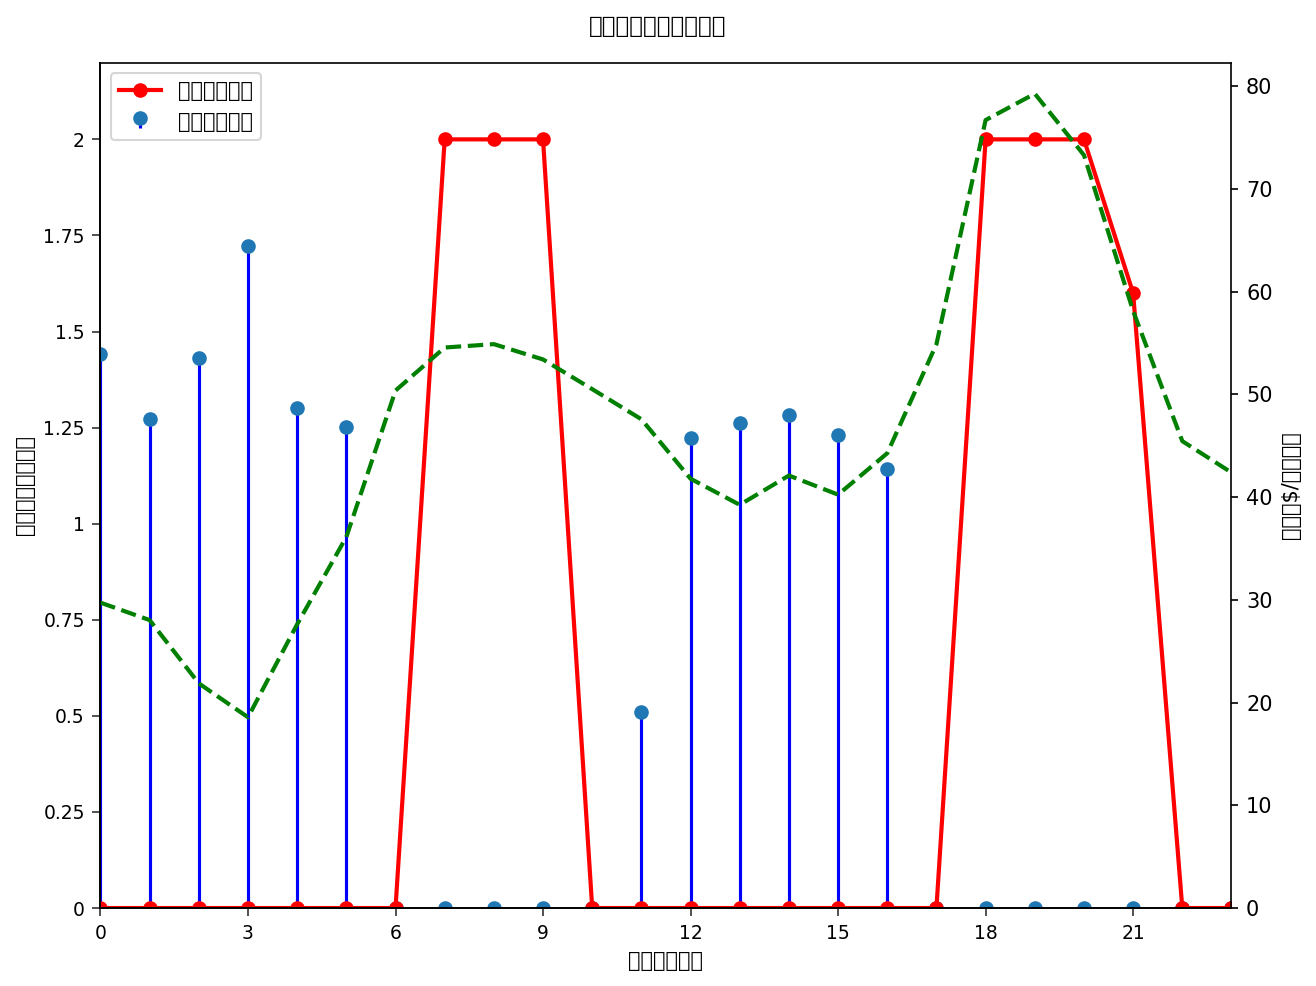

In [8]:
过程 SGPLOT 数据=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="充电（兆瓦）";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="放电（兆瓦）";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="电价（$/兆瓦时）";
    XAXIS 标签="一天中的小时" VALUES=(0 到 23 按照 3);
    YAXIS 标签="电池功率（兆瓦）" MIN=0 MAX=2.2;
    y2axis 标签="电价（$/兆瓦时）" MIN=0;
    标题 "电池充放电调度与电价";
运行;

## 9. 荷电状态轨迹

存储电能随电池夜间充满而上升，在每个放电窗口内下降，且从不突破 8 MWh 可用容量上限（点状参考线）。

                                                     关键绩效指标：套利与削峰收益                                                     




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


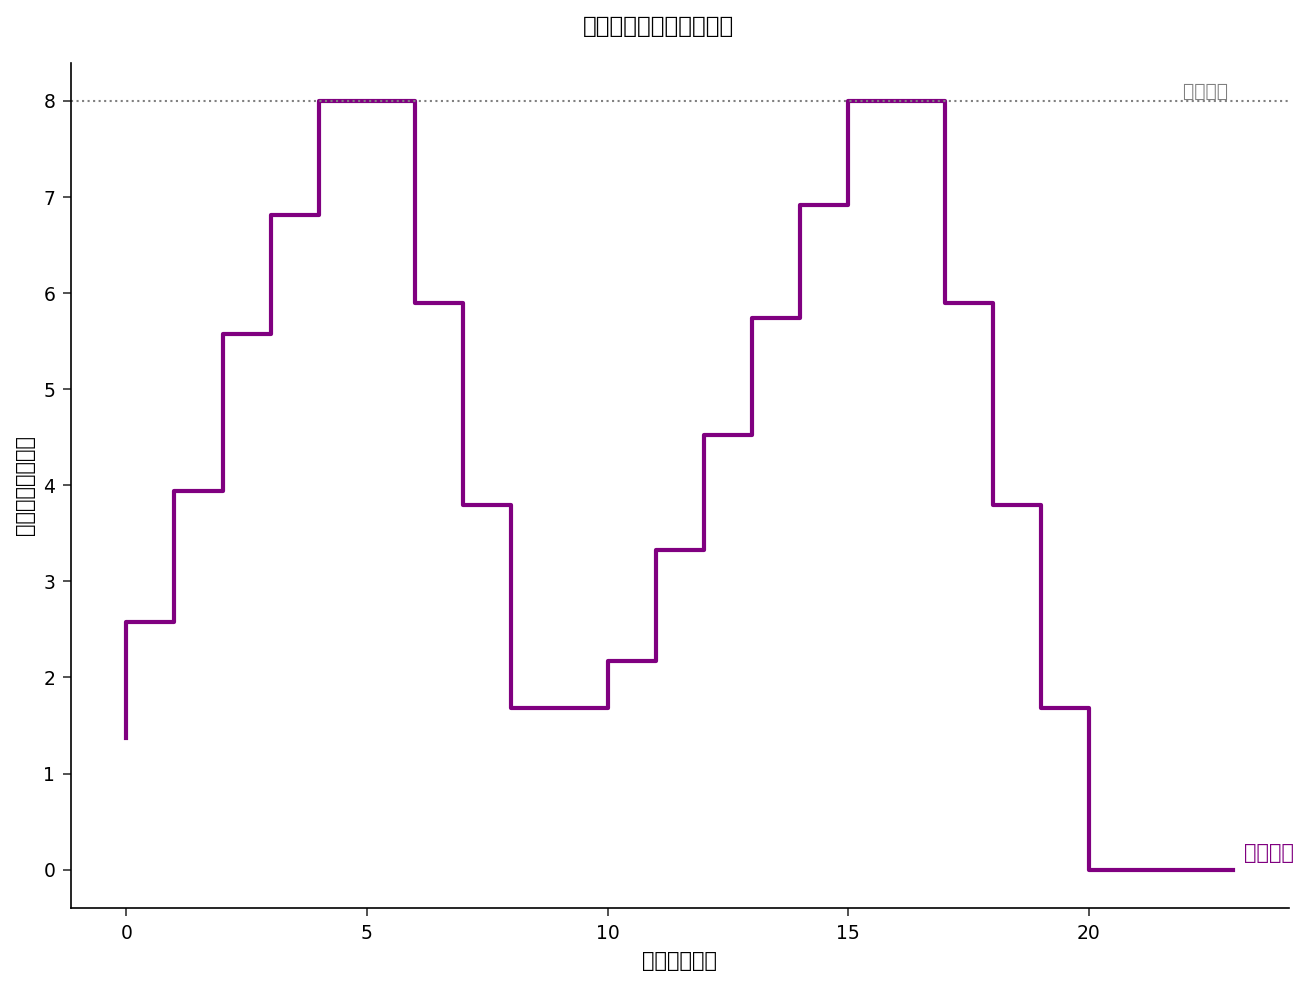

In [9]:
过程 SGPLOT 数据=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="荷电状态";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        标签="可用容量";
    XAXIS 标签="一天中的小时";
    YAXIS 标签="储能量（兆瓦时）";
    标题 "电池荷电状态随时间变化";
运行;

## 10. 电网进口：调度前后对比

橙线（含电池的电网进口）在傍晚爬坡期（18–21 时）远低于虚线基线负荷——这正是降低需量电费的削峰效应。在夜间与午间充电窗口它会上升，但优化器将其限制在约 3.43 MW 的平坦上限，该上限保持在原始 3.59 MW 负荷峰值*之下*，因此充电在买入廉价电能的同时不设立新的计费最大值。

                                                     关键绩效指标：套利与削峰收益                                                     




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


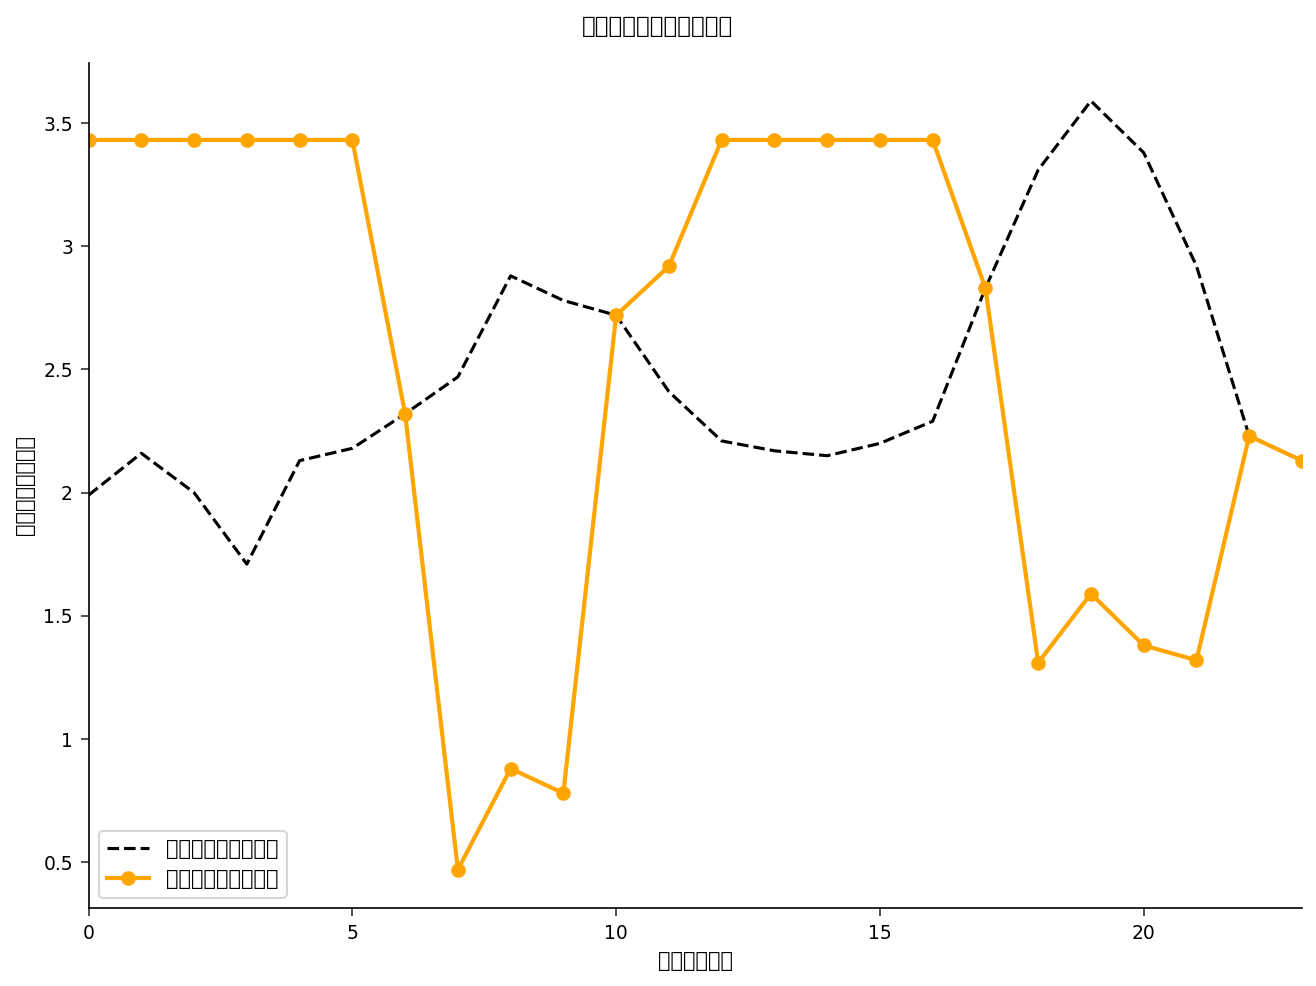

In [10]:
过程 SGPLOT 数据=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="站点负荷（无电池）";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="电网购电（含电池）";
    XAXIS 标签="一天中的小时";
    YAXIS 标签="电网购电（兆瓦）";
    标题 "削峰效果：电网购电对比";
运行;

## 解读与后续步骤

**模型的决策。** 尽管往返效率对每次循环都有损耗，优化器仍找到了明确的价值：它在最便宜的夜间小时给电池充满，向早间价格峰（7–9 时）放电，在午间价格谷（11–16 时）重新充电，并再次向最丰厚的傍晚峰（18–21 时）放电。值得注意的是，它在夜间充满期间仅以 1.0–1.7 MW 充电，而非满额 2 MW——克制功率，使新增的电网取电从不将进口推高至当日负荷峰值之上。荷电状态始终尊重 8 MWh 容量与 2 MW 功率限制。

**商业论证。** 每日电能成本从 **\$2,903.78 降至 \$2,528.43**——即 **\$375.34（12.9%）**的套利节省——同时计费的电网最大值从 **3.59 MW 降至 3.43 MW**（约 **0.16 MW**），从需量电费一项再削减 **\$18.98**。跨运行日年度化再加上经常性的需量电费下降，这正是支撑储能投资的那类利润。

**为何 LP 是正确的工具。** 启发式规则（“价格低于中位数时充电，高于时放电”）忽略了效率损失、跨小时的容量耦合，以及需量电费取决于单个区间这一事实——它们会在夜间满功率充电并*抬高*计费峰值，摧毁削峰价值。PROC OPTMODEL 在一个声明式模型中捕获所有这些，并返回可证明最优的调度，这里它有意调节充电速率以保护峰值。

**扩展模型。**

- **更长时域 / 多日**——扩大 `HOURS` 索引集；加入跨日循环限制。
- **价格不确定性**——在多个价格情景上求解 LP 并对首小时决策取平均（滚动随机策略）。
- **电池退化**——加入吞吐量惩罚项或对累积循环的约束，以在套利与资产寿命之间权衡。
- **调频 / 容量市场**——引入预留裕度约束，使电池能够在套利之上叠加辅助服务收益。

以上皆为对同一 OPTMODEL 块的增量编辑——这里建立的结构原封不动地贯穿始终。